In [1]:
import numpy as np
from astropy.io import fits
from scipy.ndimage import convolve

In [2]:
def create_circular_mask(radius):
    diameter = 2 * radius + 1
    center = radius
    y, x = np.ogrid[-center:center+1, -center:center+1]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(float)

In [3]:
def sum_in_circle(arr, radius):
    mask = create_circular_mask(radius)
    return convolve(arr, mask, mode='constant', cval=0.0)


In [4]:
chip = 'nrca1'
pointing = 6
pixscale = 0.05
radius = 50

path = f'F212N/{chip}_p{pointing}/Completeness/'

mag_min = 13.5   #minimum magnitude for which completeness is tested
mag_max = 20.5   #maximum magnitude for which completeness is tested
mag_step = 0.5 #magnitude step for which completeness is tested
mags = np.arange(mag_min,mag_max+mag_step,mag_step)
print(mags)

[13.5 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20.
 20.5]


In [5]:
#radius = 100
#inmap = fits.getdata(path + f'inmap{16:.4f}.fits')
#inmap = inmap[0:1000,0:1000]
#outmap = fits.getdata(path + f'outmap{16:.4f}.fits')
#outmap = outmap[0:1000,0:1000]
#in_summed = sum_in_circle(inmap, radius)
#out_summed = sum_in_circle(outmap, radius)
#in_summed = in_summed.astype('float64')
#out_summed = out_summed.astype('float64')
#comp_map = np.divide(out_summed, in_summed, out=np.zeros_like(in_summed), where=out_summed!=0)
#fits.writeto(f'{path}hhh.fits.gz',comp_map,overwrite=True)

In [6]:
for thismag in mags:
    inmap = fits.getdata(path + f'inmap{thismag:.1f}.fits.gz')
    outmap = fits.getdata(path + f'outmap{thismag:.1f}.fits.gz')
    print(f'Read in maps for magnitude {thismag:.1f}.')
    in_summed = sum_in_circle(inmap, radius)
    out_summed = sum_in_circle(outmap, radius)
    in_summed = in_summed.astype('float64')
    out_summed = out_summed.astype('float64')
    comp_map = np.divide(out_summed, in_summed, out=np.zeros_like(in_summed), where=out_summed!=0)
    fits.writeto(f'{path}completeness{thismag:.1f}.fits.gz',comp_map,overwrite=True)
    print(f'Processed magnitude {thismag:.1f}.')

Read in maps for magnitude 13.5.
Processed magnitude 13.5.
Read in maps for magnitude 14.0.
Processed magnitude 14.0.
Read in maps for magnitude 14.5.
Processed magnitude 14.5.
Read in maps for magnitude 15.0.
Processed magnitude 15.0.
Read in maps for magnitude 15.5.
Processed magnitude 15.5.
Read in maps for magnitude 16.0.
Processed magnitude 16.0.
Read in maps for magnitude 16.5.
Processed magnitude 16.5.
Read in maps for magnitude 17.0.
Processed magnitude 17.0.
Read in maps for magnitude 17.5.
Processed magnitude 17.5.
Read in maps for magnitude 18.0.
Processed magnitude 18.0.
Read in maps for magnitude 18.5.
Processed magnitude 18.5.
Read in maps for magnitude 19.0.
Processed magnitude 19.0.
Read in maps for magnitude 19.5.
Processed magnitude 19.5.
Read in maps for magnitude 20.0.
Processed magnitude 20.0.
Read in maps for magnitude 20.5.
Processed magnitude 20.5.


In [7]:
completeness_mean = []

for thismag in mags:  
    inmap = fits.getdata(path + f'inmap{thismag:.1f}.fits.gz')
    outmap = fits.getdata(path + f'outmap{thismag:.1f}.fits.gz')
    print(f'Read in maps for magnitude {thismag:.1f}.')

    in_summed = sum_in_circle(inmap, radius).astype('float64')
    out_summed = sum_in_circle(outmap, radius).astype('float64')
    # --- completeness promedio global ---
    total_in = np.sum(in_summed)
    total_out = np.sum(out_summed)

    comp_global = total_out / total_in if total_in > 0 else 0
    completeness_mean.append(comp_global)

    print(f'Processed magnitude {thismag:.1f}. Completeness = {comp_global:.3f}')

Read in maps for magnitude 13.5.
Processed magnitude 13.5. Completeness = 0.971
Read in maps for magnitude 14.0.
Processed magnitude 14.0. Completeness = 0.971
Read in maps for magnitude 14.5.
Processed magnitude 14.5. Completeness = 0.970
Read in maps for magnitude 15.0.
Processed magnitude 15.0. Completeness = 0.970
Read in maps for magnitude 15.5.
Processed magnitude 15.5. Completeness = 0.968
Read in maps for magnitude 16.0.
Processed magnitude 16.0. Completeness = 0.967
Read in maps for magnitude 16.5.
Processed magnitude 16.5. Completeness = 0.964
Read in maps for magnitude 17.0.
Processed magnitude 17.0. Completeness = 0.959
Read in maps for magnitude 17.5.
Processed magnitude 17.5. Completeness = 0.949
Read in maps for magnitude 18.0.
Processed magnitude 18.0. Completeness = 0.932
Read in maps for magnitude 18.5.
Processed magnitude 18.5. Completeness = 0.901
Read in maps for magnitude 19.0.
Processed magnitude 19.0. Completeness = 0.858
Read in maps for magnitude 19.5.
Process

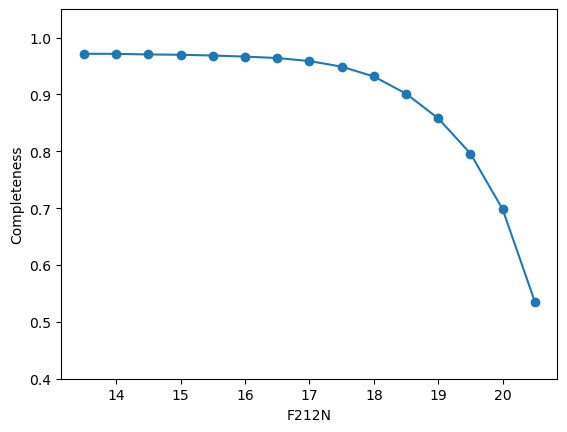

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

plt.figure()
plt.plot(mags, completeness_mean, marker='o')
plt.xlabel('F212N')
plt.ylabel('Completeness')
plt.ylim(0.4, 1.05)
#plt.gca().invert_xaxis()  # importante en astronomía
#plt.grid()
plt.show()